# Lung Diseases — Deep Feature Extraction + Machine Learning Classification (Multi‑Backbone, Thesis‑Ready)

**Goal:** Build a complete, reproducible pipeline for **lung X‑ray (or CT slice) classification** using:

1) **Deep CNNs as feature extractors** (Transfer Learning backbones)  
2) **Classical ML classifiers** on top of extracted features  
3) A final **large comparison table** (Backbone × ML model), similar in spirit to your first notebook.

✅ **You mostly edit only `DATA_DIR`** (and optionally `CLASS_ORDER`).

---

## What this notebook produces

- Leakage‑free **Train/Val/Test** split (saved to `./outputs_lung_ml/splits/`)
- **Feature matrices** saved as `.npz` per backbone
- Trained **ML models** saved as joblib per (backbone, classifier)
- Metrics per run:
  - Accuracy, Precision‑macro, Recall‑macro, F1‑macro
  - ROC‑AUC (OvR) when probabilities exist
- Plots:
  - Confusion matrix for the **best run**
  - Top‑N bar chart by chosen metric
- Final artifact:
  - `comparison_table.csv` (Backbone × Classifier)



In [1]:
# ====== 0) Install / Imports ======
# If you're on Colab, you may need:
# !pip -q install scikit-learn joblib

import os
import json
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from joblib import dump

print("TF:", tf.__version__)


TF: 2.20.0


## 1) Config (edit here)

**Folder structure expected:**
```
DATA_DIR/
  ClassA/
  ClassB/
  ClassC/
  ...
```

If you want a fixed label order (recommended for thesis), set `CLASS_ORDER` explicitly.


In [2]:
# ====== 1) CONFIG ======
DATA_DIR = Path(r"D:\gradution project\Lung X-Ray Image")   # <-- EDIT THIS
OUTPUT_DIR = Path("./outputs_lung_ml")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15   # from remaining after test split
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Optional: Fix class order (set to None to infer from folders in alphabetical order)
# Example:
# CLASS_ORDER = ["Normal", "Lung Opacity", "Viral Pneumonia"]
CLASS_ORDER = None

# Which metric to rank "best" run:
RANK_BY = "f1_macro"   # options: accuracy, precision_macro, recall_macro, f1_macro, roc_auc_ovr

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("DATA_DIR:", DATA_DIR.resolve())


DATA_DIR: D:\gradution project\Lung X-Ray Image


## 2) Build file list + leakage‑free stratified split

We split on **file paths** first (before any augmentation / dataset creation).
Splits are saved to disk for reproducibility.


In [3]:
def list_image_files(data_dir: Path, class_order=None):
    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR not found: {data_dir}")

    class_dirs = [p for p in data_dir.iterdir() if p.is_dir()]
    if class_order is None:
        class_names = sorted([p.name for p in class_dirs])
    else:
        class_names = list(class_order)
        missing = [c for c in class_names if not (data_dir / c).exists()]
        if missing:
            raise ValueError(f"CLASS_ORDER has missing folders: {missing}")

    rows = []
    for label, cname in enumerate(class_names):
        folder = data_dir / cname
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
        files = [p for p in folder.rglob("*") if p.suffix.lower() in exts]
        for f in files:
            rows.append({"path": str(f), "label": label, "class_name": cname})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No images found. Check DATA_DIR and extensions.")
    return df, class_names

df_all, CLASS_NAMES = list_image_files(DATA_DIR, CLASS_ORDER)
print("Classes:", CLASS_NAMES)
print("Total images:", len(df_all))
df_all.head()


Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Total images: 3475


,path,label,class_name
0,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
1,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
2,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
3,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity
4,D:\gradution project\Lung X-Ray Image\Lung_Opa...,0,Lung_Opacity


In [4]:
# Stratified train/val/test split
df_trainval, df_test = train_test_split(
    df_all, test_size=TEST_SIZE, random_state=SEED, stratify=df_all["label"]
)

# val from trainval
val_frac_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_frac_of_trainval, random_state=SEED, stratify=df_trainval["label"]
)

print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))

# Save splits
splits_dir = OUTPUT_DIR / "splits"
splits_dir.mkdir(exist_ok=True, parents=True)
df_train.to_csv(splits_dir / "train.csv", index=False)
df_val.to_csv(splits_dir / "val.csv", index=False)
df_test.to_csv(splits_dir / "test.csv", index=False)

# Save label mapping
with open(splits_dir / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"class_names": CLASS_NAMES}, f, ensure_ascii=False, indent=2)

pd.DataFrame({
    "split": ["train","val","test"],
    "n": [len(df_train), len(df_val), len(df_test)]
})


Train: 2431 Val: 522 Test: 522


,split,n
0,train,2431
1,val,522
2,test,522


## 3) tf.data pipeline (decode → resize → (optional) augmentation)

For feature extraction we keep augmentations **light** and on **train only**.  
You can turn augmentation off by setting `AUGMENT = False`.


In [5]:
AUGMENT = True

augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augmenter")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32)
    return img, label

def make_ds(df: pd.DataFrame, training: bool):
    paths = df["path"].values
    labels = df["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y), num_parallel_calls=tf.data.AUTOTUNE)
    if training and AUGMENT:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

ds_train_raw = make_ds(df_train, training=True)
ds_val_raw   = make_ds(df_val, training=False)
ds_test_raw  = make_ds(df_test, training=False)

# Quick sanity check
for batch_imgs, batch_y in ds_train_raw.take(1):
    print(batch_imgs.shape, batch_y.shape, batch_imgs.dtype)


(32, 224, 224, 3) (32,) <dtype: 'float32'>


## 4) Backbones (Deep Feature Extractors)

We’ll extract **GlobalAveragePooling** features for each backbone.


In [6]:
from tensorflow.keras.applications import (
    MobileNetV2, EfficientNetB0, ResNet50, DenseNet121
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pp_mnv2
from tensorflow.keras.applications.efficientnet import preprocess_input as pp_effb0
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_res50
from tensorflow.keras.applications.densenet import preprocess_input as pp_d121

BACKBONES = {
    "MobileNetV2": (MobileNetV2, pp_mnv2),
    "EfficientNetB0": (EfficientNetB0, pp_effb0),
    "ResNet50": (ResNet50, pp_res50),
    "DenseNet121": (DenseNet121, pp_d121),
}

def build_feature_extractor(backbone_name: str):
    ctor, preprocess = BACKBONES[backbone_name]
    base = ctor(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    inp = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = preprocess(inp)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    model = tf.keras.Model(inp, x, name=f"{backbone_name}_feature_extractor")
    return model

# Inspect feature dimension
tmp = build_feature_extractor("MobileNetV2")
tmp.output_shape


(None, 1280)

## 5) Feature extraction (train/val/test) + save to disk

We save `.npz` files so you can reuse features without re-running TensorFlow.


In [7]:
def extract_features(model: tf.keras.Model, ds: tf.data.Dataset):
    feats = []
    labels = []
    for xb, yb in ds:
        fb = model(xb, training=False).numpy()
        feats.append(fb)
        labels.append(yb.numpy())
    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)
    return X, y

features_dir = OUTPUT_DIR / "features"
features_dir.mkdir(parents=True, exist_ok=True)

feature_sets = {}  # backbone -> dict of X/y per split

for bname in BACKBONES.keys():
    print(f"\n=== Extracting: {bname} ===")
    fe_model = build_feature_extractor(bname)

    Xtr, ytr = extract_features(fe_model, ds_train_raw)
    Xva, yva = extract_features(fe_model, ds_val_raw)
    Xte, yte = extract_features(fe_model, ds_test_raw)

    # Save
    np.savez_compressed(features_dir / f"{bname}_train.npz", X=Xtr, y=ytr)
    np.savez_compressed(features_dir / f"{bname}_val.npz",   X=Xva, y=yva)
    np.savez_compressed(features_dir / f"{bname}_test.npz",  X=Xte, y=yte)

    feature_sets[bname] = {"train": (Xtr,ytr), "val": (Xva,yva), "test": (Xte,yte)}
    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)



=== Extracting: MobileNetV2 ===
Shapes: (2431, 1280) (522, 1280) (522, 1280)

=== Extracting: EfficientNetB0 ===
Shapes: (2431, 1280) (522, 1280) (522, 1280)

=== Extracting: ResNet50 ===
Shapes: (2431, 2048) (522, 2048) (522, 2048)

=== Extracting: DenseNet121 ===
Shapes: (2431, 1024) (522, 1024) (522, 1024)


## 6) ML models (multiple classifiers for each backbone)

We standardize features (fit on train only) then train:
- Logistic Regression
- SVM (RBF, probability)
- Linear SVM + Calibration (to get probabilities)
- Random Forest

You can add more (e.g., XGBoost) if installed.


In [8]:
def get_ml_models(num_classes: int):
    models = {}

    # Logistic Regression (multiclass)
    models["LogReg"] = LogisticRegression(
        max_iter=5000, n_jobs=-1, multi_class="auto"
    )

    # SVC RBF with probability (can be slower on large data)
    models["SVC_RBF"] = SVC(
        kernel="rbf", C=3.0, gamma="scale", probability=True
    )

    # LinearSVC + calibration to get predict_proba
    base_linsvc = LinearSVC(C=1.0)
    models["LinearSVC_Calibrated"] = CalibratedClassifierCV(base_linsvc, method="sigmoid", cv=3)

    # Random Forest
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=400, random_state=SEED, n_jobs=-1
    )

    return models

NUM_CLASSES = len(CLASS_NAMES)
ml_models = get_ml_models(NUM_CLASSES)
list(ml_models.keys())


['LogReg', 'SVC_RBF', 'LinearSVC_Calibrated', 'RandomForest']

## 7) Train + Evaluate all (Backbone × ML) and build the big comparison table

In [9]:
models_dir = OUTPUT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)

runs = []

def safe_roc_auc_ovr(y_true, proba, num_classes):
    # y_true shape: (n,), proba shape: (n, C)
    try:
        if num_classes == 2:
            # For binary, roc_auc_score expects scores for positive class
            return float(roc_auc_score(y_true, proba[:, 1]))
        else:
            return float(roc_auc_score(y_true, proba, multi_class="ovr"))
    except Exception:
        return np.nan

for bname, splits in feature_sets.items():
    Xtr, ytr = splits["train"]
    Xva, yva = splits["val"]
    Xte, yte = splits["test"]

    # Standardize (fit on train only)
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xva_s = scaler.transform(Xva)
    Xte_s = scaler.transform(Xte)

    # Save scaler
    dump(scaler, models_dir / f"{bname}__scaler.joblib")

    for mname, clf in ml_models.items():
        print(f"Training: {bname} + {mname}")
        t0 = time.time()
        clf.fit(Xtr_s, ytr)
        train_time = time.time() - t0

        # Validation metrics (to rank & select best)
        yva_pred = clf.predict(Xva_s)
        acc = accuracy_score(yva, yva_pred)
        prec = precision_score(yva, yva_pred, average="macro", zero_division=0)
        rec = recall_score(yva, yva_pred, average="macro", zero_division=0)
        f1 = f1_score(yva, yva_pred, average="macro", zero_division=0)

        # Probabilities for ROC-AUC if available
        if hasattr(clf, "predict_proba"):
            proba_va = clf.predict_proba(Xva_s)
            roc = safe_roc_auc_ovr(yva, proba_va, NUM_CLASSES)
        else:
            roc = np.nan

        run = {
            "backbone": bname,
            "classifier": mname,
            "val_accuracy": acc,
            "val_precision_macro": prec,
            "val_recall_macro": rec,
            "val_f1_macro": f1,
            "val_roc_auc_ovr": roc,
            "train_time_sec": train_time,
            "n_train": len(ytr),
            "n_val": len(yva),
            "n_test": len(yte),
            "feature_dim": Xtr.shape[1],
        }
        runs.append(run)

        # Save model
        dump(clf, models_dir / f"{bname}__{mname}.joblib")

comparison = pd.DataFrame(runs).sort_values(
    by=f"val_{RANK_BY}" if RANK_BY != "roc_auc_ovr" else "val_roc_auc_ovr",
    ascending=False
).reset_index(drop=True)

comparison_path = OUTPUT_DIR / "comparison_table.csv"
comparison.to_csv(comparison_path, index=False)

comparison.head(10)


Training: MobileNetV2 + LogReg


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training: MobileNetV2 + SVC_RBF
Training: MobileNetV2 + LinearSVC_Calibrated
Training: MobileNetV2 + RandomForest
Training: EfficientNetB0 + LogReg


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training: EfficientNetB0 + SVC_RBF
Training: EfficientNetB0 + LinearSVC_Calibrated
Training: EfficientNetB0 + RandomForest
Training: ResNet50 + LogReg


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training: ResNet50 + SVC_RBF
Training: ResNet50 + LinearSVC_Calibrated
Training: ResNet50 + RandomForest
Training: DenseNet121 + LogReg


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training: DenseNet121 + SVC_RBF
Training: DenseNet121 + LinearSVC_Calibrated
Training: DenseNet121 + RandomForest


,backbone,classifier,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc_ovr,train_time_sec,n_train,n_val,n_test,feature_dim
0,DenseNet121,SVC_RBF,0.913793,0.919093,0.914041,0.915753,0.981997,9.468686,2431,522,522,1024
1,ResNet50,LinearSVC_Calibrated,0.908046,0.912025,0.908866,0.909839,0.970136,4.011851,2431,522,522,2048
2,ResNet50,SVC_RBF,0.904215,0.905211,0.906516,0.905798,0.977061,28.577298,2431,522,522,2048
3,MobileNetV2,SVC_RBF,0.900383,0.900469,0.903767,0.901304,0.972469,16.005681,2431,522,522,1280
4,ResNet50,RandomForest,0.896552,0.898665,0.898379,0.897798,0.973563,4.294979,2431,522,522,2048
5,DenseNet121,RandomForest,0.894636,0.896262,0.896654,0.895821,0.976003,3.570592,2431,522,522,1024
6,DenseNet121,LinearSVC_Calibrated,0.892720,0.904096,0.891699,0.893616,0.974571,20.210606,2431,522,522,1024
7,MobileNetV2,RandomForest,0.892720,0.892374,0.896276,0.893297,0.970228,2.931966,2431,522,522,1280
8,DenseNet121,LogReg,0.890805,0.904176,0.889679,0.892507,0.971899,3.246660,2431,522,522,1024
9,EfficientNetB0,SVC_RBF,0.888889,0.890044,0.892634,0.890636,0.970617,15.595782,2431,522,522,1280


## 8) Pick best run (by validation) → Evaluate on Test + plots

In [10]:
# Choose best row
best = comparison.iloc[0].to_dict()
best


{'backbone': 'DenseNet121',
 'classifier': 'SVC_RBF',
 'val_accuracy': 0.9137931034482759,
 'val_precision_macro': 0.9190933466359045,
 'val_recall_macro': 0.9140413959562895,
 'val_f1_macro': 0.9157527614287518,
 'val_roc_auc_ovr': 0.9819967818276147,
 'train_time_sec': 9.468685865402222,
 'n_train': 2431,
 'n_val': 522,
 'n_test': 522,
 'feature_dim': 1024}

In [11]:
# Load best scaler + model
best_backbone = best["backbone"]
best_clf_name = best["classifier"]

best_scaler = None
best_model = None

from joblib import load
best_scaler = load(models_dir / f"{best_backbone}__scaler.joblib")
best_model  = load(models_dir / f"{best_backbone}__{best_clf_name}.joblib")

# Prepare test set
Xte, yte = feature_sets[best_backbone]["test"]
Xte_s = best_scaler.transform(Xte)

y_pred = best_model.predict(Xte_s)

test_metrics = {
    "test_accuracy": float(accuracy_score(yte, y_pred)),
    "test_precision_macro": float(precision_score(yte, y_pred, average="macro", zero_division=0)),
    "test_recall_macro": float(recall_score(yte, y_pred, average="macro", zero_division=0)),
    "test_f1_macro": float(f1_score(yte, y_pred, average="macro", zero_division=0)),
}

if hasattr(best_model, "predict_proba"):
    proba_te = best_model.predict_proba(Xte_s)
    test_metrics["test_roc_auc_ovr"] = safe_roc_auc_ovr(yte, proba_te, NUM_CLASSES)
else:
    test_metrics["test_roc_auc_ovr"] = np.nan

test_metrics


{'test_accuracy': 0.9099616858237548,
 'test_precision_macro': 0.9130046478091387,
 'test_recall_macro': 0.9108939705502718,
 'test_f1_macro': 0.9116882227007492,
 'test_roc_auc_ovr': 0.9833519089606132}

In [12]:
# Classification report
print("Best run:", best_backbone, "+", best_clf_name)
print(classification_report(yte, y_pred, target_names=CLASS_NAMES, zero_division=0))


Best run: DenseNet121 + SVC_RBF
                 precision    recall  f1-score   support

   Lung_Opacity       0.90      0.86      0.88       169
         Normal       0.86      0.90      0.88       188
Viral Pneumonia       0.98      0.98      0.98       165

       accuracy                           0.91       522
      macro avg       0.91      0.91      0.91       522
   weighted avg       0.91      0.91      0.91       522



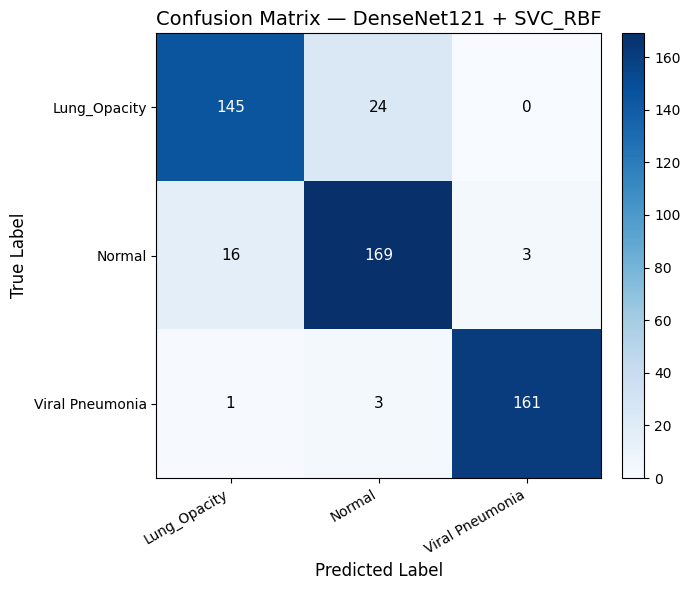

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yte, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, interpolation='nearest', cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)

ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_backbone} + {best_clf_name}", fontsize=14)

# كتابة الأرقام داخل الخلايا
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=11
        )

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

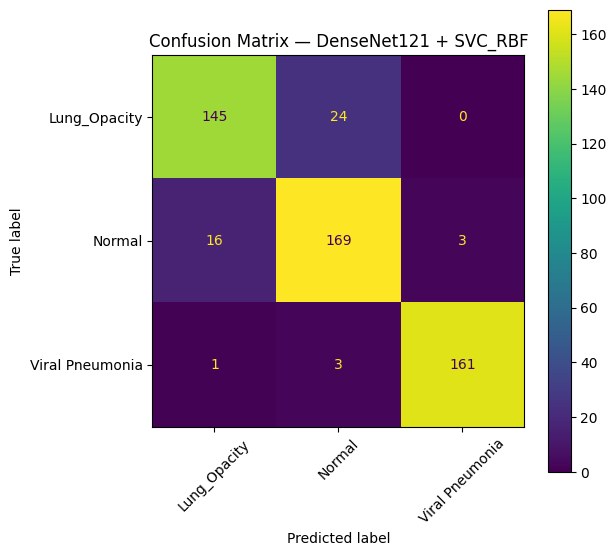

In [13]:
# Confusion matrix
cm = confusion_matrix(yte, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix — {best_backbone} + {best_clf_name}")
plt.show()


## 9) Big comparison chart (Top‑N runs)

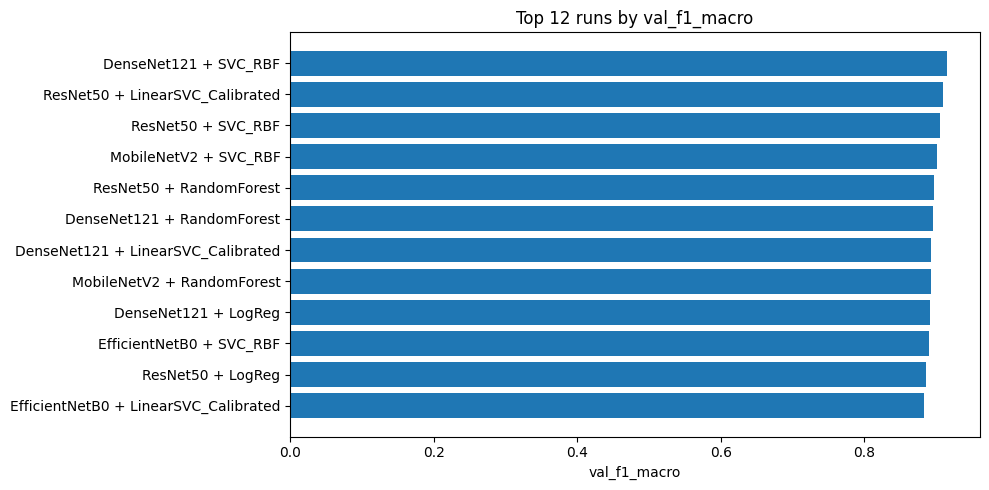

,backbone,classifier,val_f1_macro,train_time_sec,feature_dim
0,DenseNet121,SVC_RBF,0.915753,9.468686,1024
1,ResNet50,LinearSVC_Calibrated,0.909839,4.011851,2048
2,ResNet50,SVC_RBF,0.905798,28.577298,2048
3,MobileNetV2,SVC_RBF,0.901304,16.005681,1280
4,ResNet50,RandomForest,0.897798,4.294979,2048
5,DenseNet121,RandomForest,0.895821,3.570592,1024
6,DenseNet121,LinearSVC_Calibrated,0.893616,20.210606,1024
7,MobileNetV2,RandomForest,0.893297,2.931966,1280
8,DenseNet121,LogReg,0.892507,3.246660,1024
9,EfficientNetB0,SVC_RBF,0.890636,15.595782,1280


In [14]:
TOP_N = 12
metric_col = f"val_{RANK_BY}" if RANK_BY != "roc_auc_ovr" else "val_roc_auc_ovr"

top = comparison.head(TOP_N).copy()
top["run"] = top["backbone"] + " + " + top["classifier"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top["run"][::-1], top[metric_col][::-1])
ax.set_xlabel(metric_col)
ax.set_title(f"Top {TOP_N} runs by {metric_col}")
plt.tight_layout()
plt.show()

top[[ "backbone","classifier", metric_col, "train_time_sec", "feature_dim" ]]


## 10) Notes / next step

- This notebook is the **Feature Extraction + ML** path.
- Keep your deep end‑to‑end notebook as the **second path** (CNN classifier directly).
- After you finish both, we can merge results into one thesis table:
  - Deep End‑to‑End best models
  - Feature‑based best models
  - Side‑by‑side comparison
